In [53]:
# !pip install numpy matplotlib pandas seaborn scipy

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

df = pd.read_csv('../data/monthly_mocha.csv')

In [27]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    74 non-null     object 
 1   subscriptions           74 non-null     int64  
 2   meta_spend              74 non-null     float64
 3   meta_impressions        74 non-null     int64  
 4   google_spend            74 non-null     float64
 5   google_impressions      74 non-null     int64  
 6   snapchat_spend          74 non-null     float64
 7   snapchat_impressions    74 non-null     int64  
 8   tiktok_spend            74 non-null     float64
 9   tiktok_impressions      74 non-null     int64  
 10  moloco_spend            74 non-null     float64
 11  moloco_impressions      74 non-null     int64  
 12  liveintent_spend        74 non-null     float64
 13  liveintent_impressions  74 non-null     int64  
 14  roku_spend              74 non-null     int6

,subscriptions,meta_spend,meta_impressions,google_spend,google_impressions,snapchat_spend,snapchat_impressions,tiktok_spend,tiktok_impressions,moloco_spend,moloco_impressions,liveintent_spend,liveintent_impressions,roku_spend,roku_impressions,beehiiv_spend,beehiiv_impressions,amazon_spend,amazon_impressions
count,74.000000,74.000000,7.400000e+01,74.000000,7.400000e+01,74.000000,7.400000e+01,74.000000,7.400000e+01,74.000000,7.400000e+01,74.000000,74.000000,74.0,74.0,74.000000,74.000000,74.000000,74.000000
mean,12387.702703,11353.488196,2.602940e+06,139169.512793,6.218196e+06,58681.579851,2.708208e+06,23684.932556,1.080475e+06,11381.548778,5.079325e+05,10783.610447,121067.702703,0.0,0.0,4434.760449,44347.459459,212.706190,9685.486486
std,2549.657005,22470.904024,5.191146e+06,97693.235584,4.350068e+06,21294.910439,1.144943e+06,26496.021750,1.237887e+06,16687.824018,7.600015e+05,9206.866703,105540.045826,0.0,0.0,7433.105581,74330.934434,1175.917897,53851.739886
min,8427.000000,0.000000,0.000000e+00,43667.361380,1.787087e+06,14761.393560,6.923030e+05,0.000000,0.000000e+00,212.044372,1.115600e+04,3100.943069,35929.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
25%,10496.750000,0.000000,0.000000e+00,69310.479480,3.273862e+06,41960.953975,1.934941e+06,0.000000,0.000000e+00,1362.456143,7.261625e+04,5298.857127,66120.750000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
50%,11580.500000,0.000000,0.000000e+00,93560.281425,4.437708e+06,57704.444250,2.643654e+06,13010.537965,6.269270e+05,5650.239904,2.386730e+05,8668.567876,91934.500000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
75%,14489.500000,4320.076599,7.711222e+05,200724.755775,7.993241e+06,77598.956688,3.280520e+06,45276.766082,2.009204e+06,15420.997742,6.007465e+05,11061.373115,114096.000000,0.0,0.0,8495.817779,84957.250000,0.000000,0.000000
max,20113.000000,93840.186120,2.530060e+07,394137.771900,2.204730e+07,99447.232180,5.445542e+06,80920.812910,4.291224e+06,94285.788540,4.615385e+06,40561.340060,570418.000000,0.0,0.0,24097.344260,240973.000000,9024.064725,416194.000000


In [28]:
df.isna().sum()

date                      0
subscriptions             0
meta_spend                0
meta_impressions          0
google_spend              0
google_impressions        0
snapchat_spend            0
snapchat_impressions      0
tiktok_spend              0
tiktok_impressions        0
moloco_spend              0
moloco_impressions        0
liveintent_spend          0
liveintent_impressions    0
roku_spend                0
roku_impressions          0
beehiiv_spend             0
beehiiv_impressions       0
amazon_spend              0
amazon_impressions        0
dtype: int64

In [29]:
spend_cols = [col for col in df.columns if "spend" in col.lower()]
nonzero_spend = {}

for col in spend_cols:
    print(f"\n--- {col} ---")

    zero_pct = (df[col] == 0).mean()
    print(f"Percent of zero values: {zero_pct:.2%}")

    non_zero = df.loc[df[col] > 0, col]
    nonzero_spend[col] = non_zero.reset_index(drop=True)


--- meta_spend ---
Percent of zero values: 74.32%

--- google_spend ---
Percent of zero values: 0.00%

--- snapchat_spend ---
Percent of zero values: 0.00%

--- tiktok_spend ---
Percent of zero values: 47.30%

--- moloco_spend ---
Percent of zero values: 0.00%

--- liveintent_spend ---
Percent of zero values: 0.00%

--- roku_spend ---
Percent of zero values: 100.00%

--- beehiiv_spend ---
Percent of zero values: 66.22%

--- amazon_spend ---
Percent of zero values: 95.95%


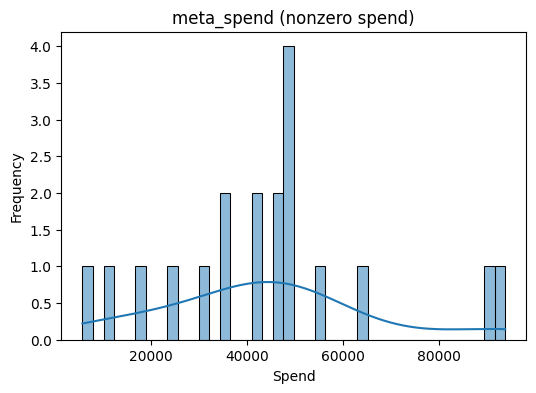

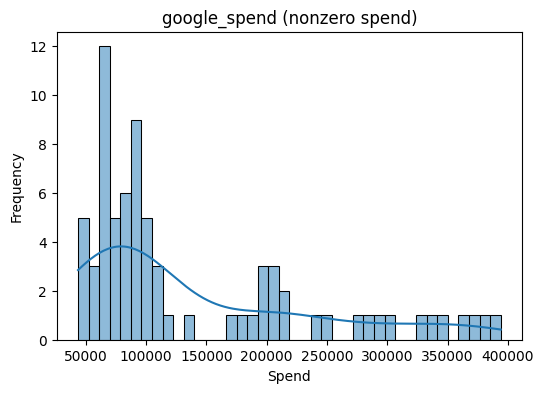

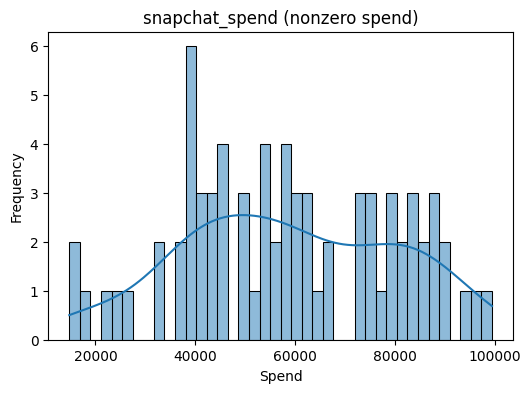

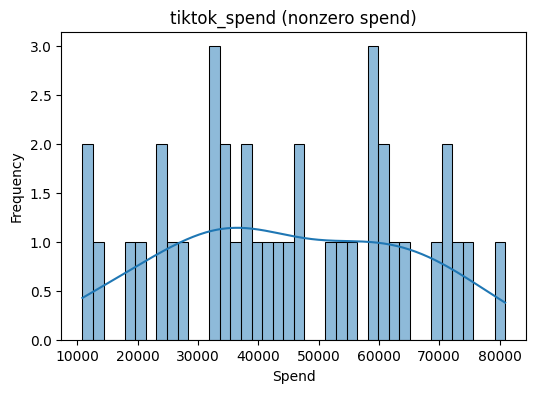

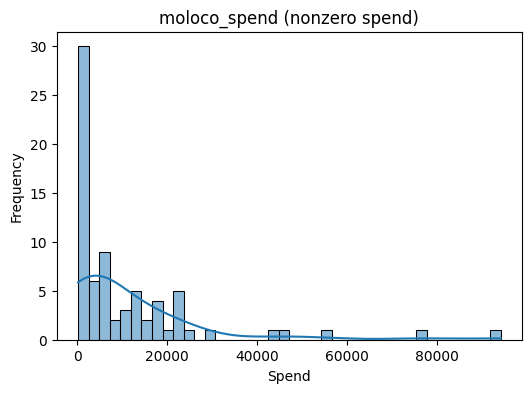

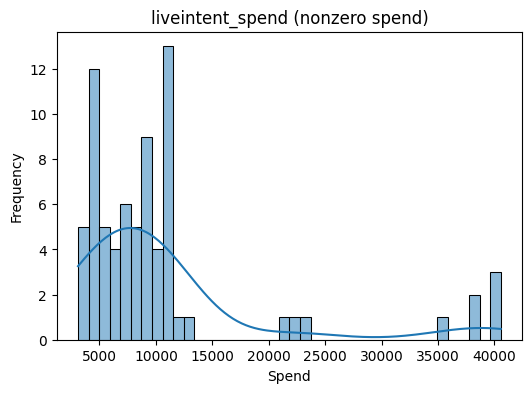

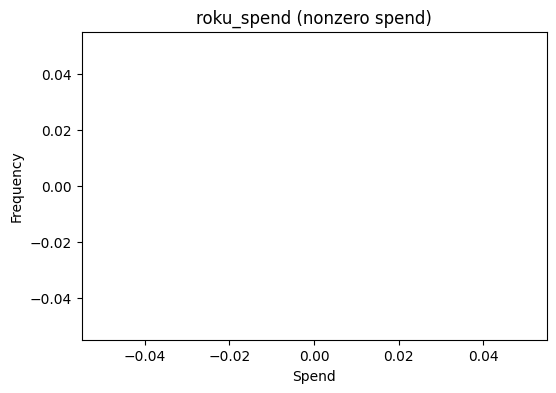

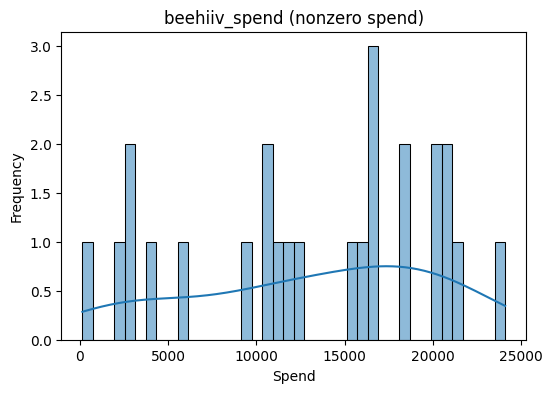

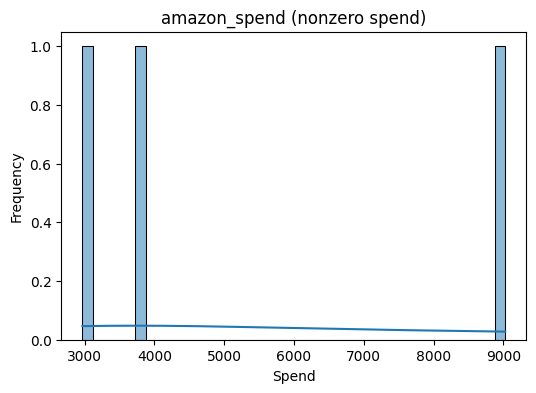

In [30]:
# plot histograms for nonzero spend values for each channel

for col in spend_cols:
    x = df[col]
    x_nz = x[x > 0]

    plt.figure(figsize=(6,4))

    sns.histplot(x_nz, bins=40, kde=True)

    plt.title(f"{col} (nonzero spend)")
    plt.xlabel("Spend")
    plt.ylabel("Frequency")

    plt.show()


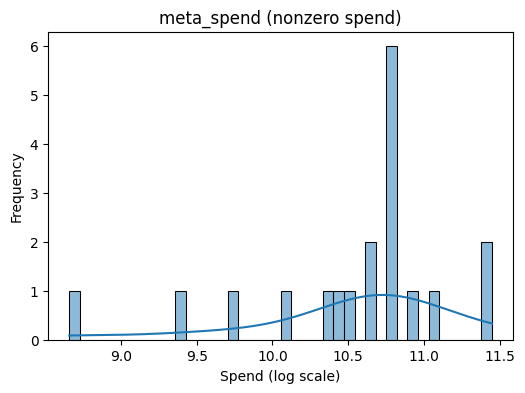

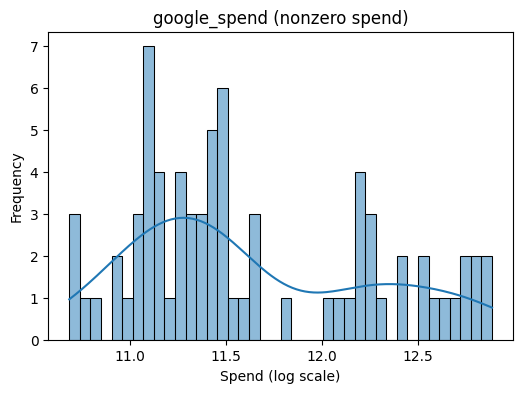

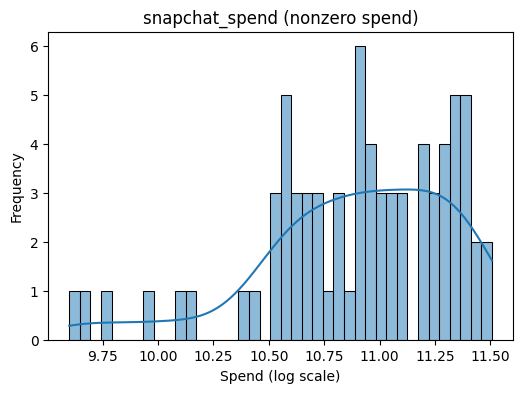

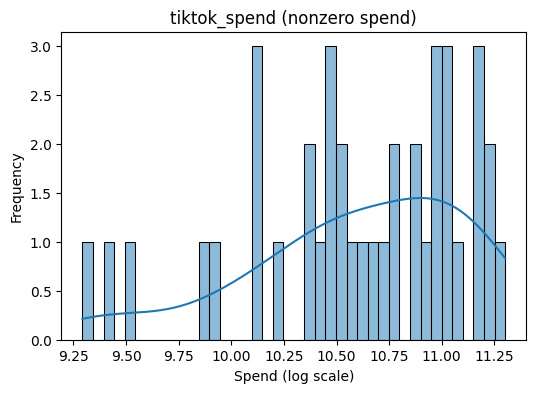

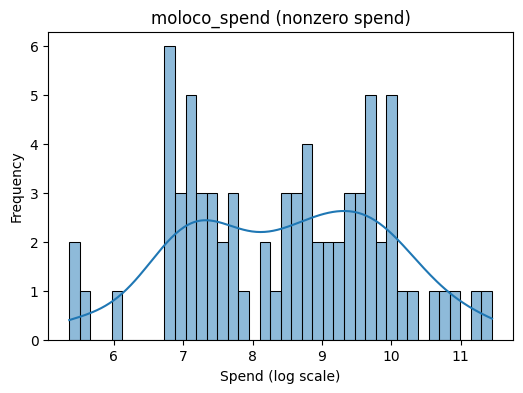

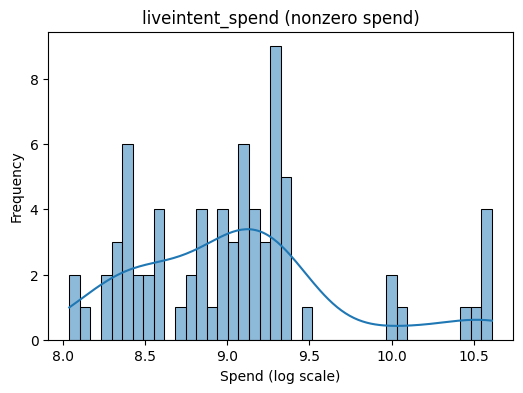

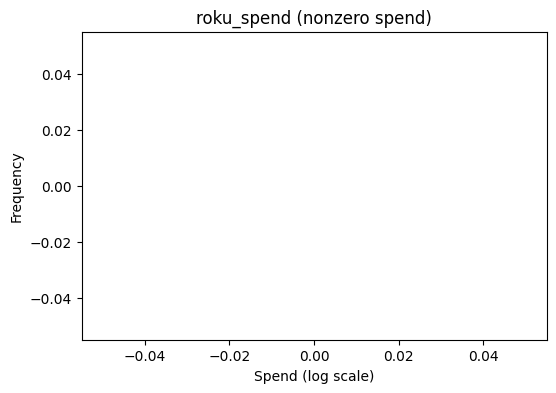

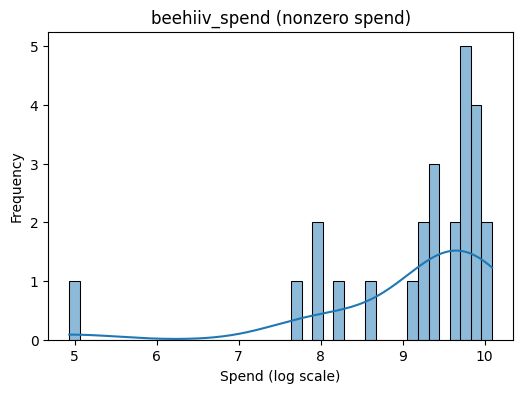

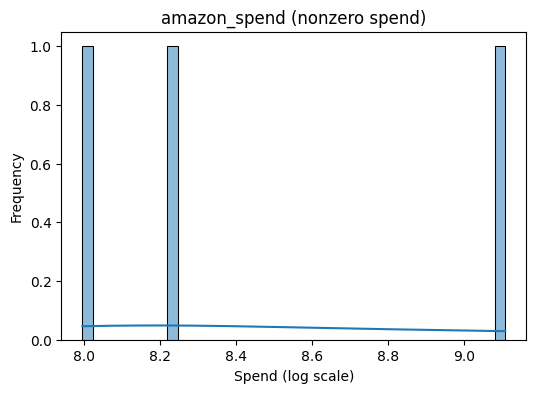

In [31]:
# same as above but with log scale on x-axis

for col in spend_cols:
    x = df[col]
    x_nz = x[x > 0]

    plt.figure(figsize=(6,4))

    sns.histplot(np.log(x_nz), bins=40, kde=True)

    plt.title(f"{col} (nonzero spend)")
    plt.xlabel("Spend (log scale)")
    plt.ylabel("Frequency")

    plt.show()

As none of the log histograms follow a normal distribution, we decide to model the channel spends with the gamma distribution.

In [32]:
# remove roku column in nonzero_spend
del nonzero_spend['roku_spend']

df_clean = df.copy()
df_clean.drop(columns=['roku_spend'], inplace=True)

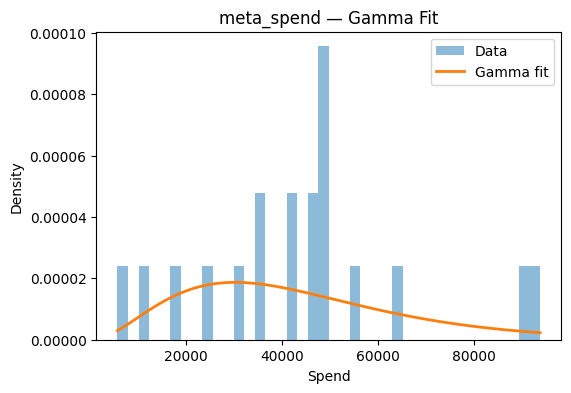

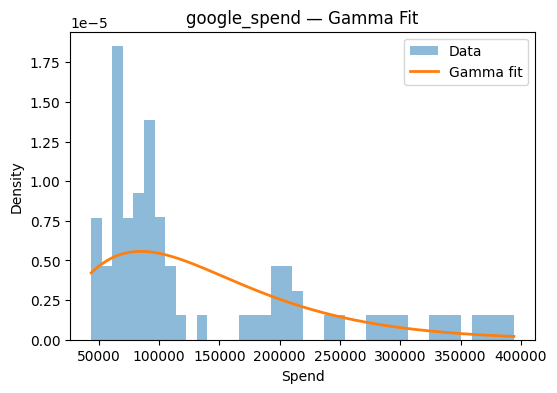

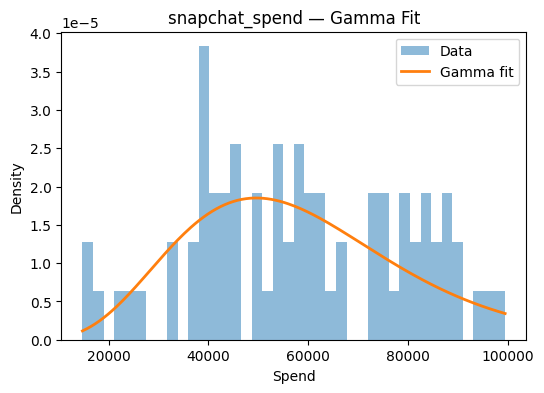

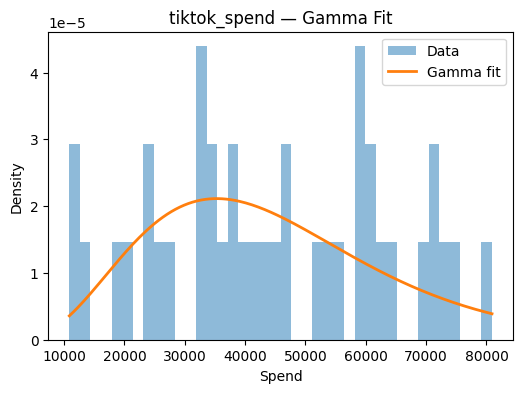

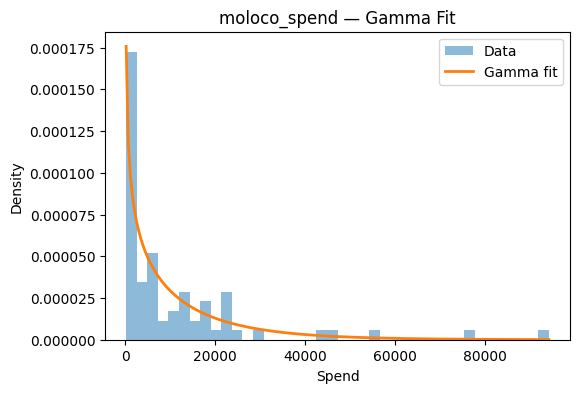

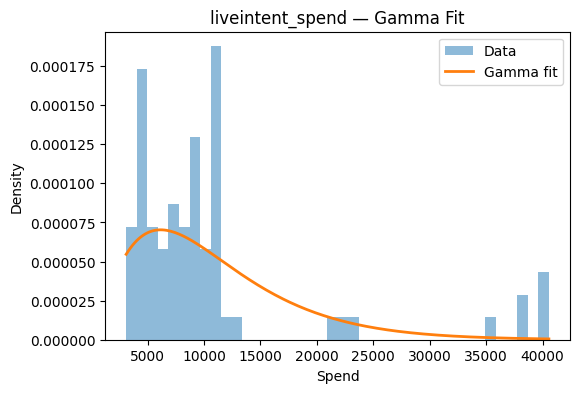

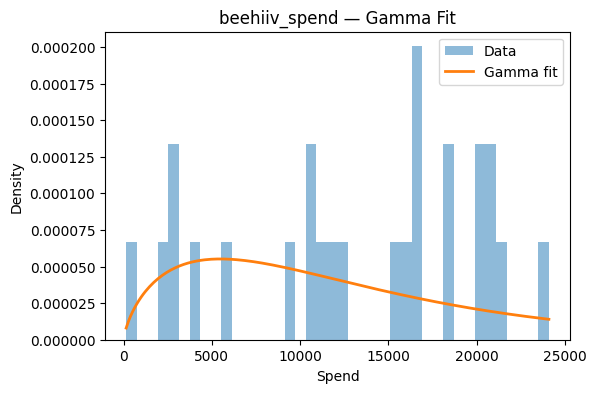

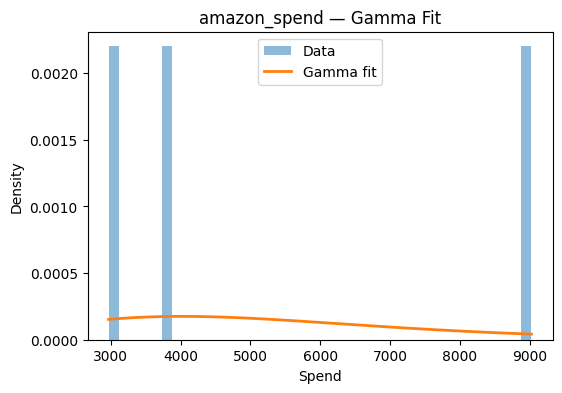

In [36]:
from scipy.stats import gamma

spend_cols = [col for col in df_clean.columns if "spend" in col.lower()]
gamma_params = {}

for col in spend_cols:
    x = nonzero_spend[col]

    # fit gamma distribution
    shape, loc, scale = gamma.fit(x, floc=0)

    # store parameters for generator
    gamma_params[col] = {
        "shape": shape,
        "scale": scale
    }

    xs = np.linspace(x.min(), x.max(), 200)

    plt.figure(figsize=(6,4))

    plt.hist(x, bins=40, density=True, alpha=0.5, label="Data")
    plt.plot(xs, gamma.pdf(xs, shape, loc=loc, scale=scale),
                label="Gamma fit", linewidth=2)

    plt.title(f"{col} — Gamma Fit")
    plt.xlabel("Spend")
    plt.ylabel("Density")
    plt.legend()

    plt.show()


In [ ]:
for col in spend_cols

{'meta_spend': {'shape': 3.173808515348445, 'scale': np.float64(13932.424892829777)}, 'google_spend': {'shape': 2.5609173779685848, 'scale': np.float64(54343.61685770668)}, 'snapchat_spend': {'shape': 6.45429402930867, 'scale': np.float64(9091.866528662265)}, 'tiktok_spend': {'shape': 4.65465559052423, 'scale': np.float64(9654.98743907756)}, 'moloco_spend': {'shape': 0.6897375943322629, 'scale': np.float64(16501.273631811873)}, 'liveintent_spend': {'shape': 2.3304082549480376, 'scale': np.float64(4627.348201379402)}, 'beehiiv_spend': {'shape': 1.7160845987364879, 'scale': np.float64(7649.326227924321)}, 'amazon_spend': {'shape': 4.28334251042827, 'scale': np.float64(1224.9201844648665)}}


Now that we chose the distributions for the spend data, we model a causal diagram of
$$
spend \Rightarrow impressions \Rightarrow revenue.
$$

We assume a heteroskedastic linear relationship between spend and impressions, where
$$
Impressions_{t,c} = \alpha_c \cdot Spend_{t,c} \cdot (1 + \epsilon_{t,c}).
$$

In [43]:
impression_params = {}

for col in spend_cols:
    imp_col = col.replace("spend", "impressions")

    spend = df[col].values
    impressions = df[imp_col].values

    # remove invalid values
    mask = (spend > 0) & np.isfinite(spend) & np.isfinite(impressions)

    spend = spend[mask]
    impressions = impressions[mask]

    # # fit SLR (no intercept)
    alpha = np.sum(spend * impressions) / np.sum(spend**2)

    # compute residuals
    residuals = (impressions - alpha * spend) / (alpha * spend)

    # estimate sigma
    sigma_rel = np.std(residuals, ddof=1)

    impression_params[col] = {
        "alpha": alpha,
        "sigma_rel": sigma_rel
    }

    channel = col.replace("_spend", "").capitalize()

    print(
        f"For channel {channel}, the spend to impressions model "
        f"estimates alpha = {alpha:.3f}, "
        f"with noise sigma = {sigma_rel:.3f}."
    )

For channel Meta, the spend to impressions model estimates alpha = 225.954, with noise sigma = 0.229.
For channel Google, the spend to impressions model estimates alpha = 43.758, with noise sigma = 0.218.
For channel Snapchat, the spend to impressions model estimates alpha = 46.066, with noise sigma = 0.208.
For channel Tiktok, the spend to impressions model estimates alpha = 45.239, with noise sigma = 0.217.
For channel Moloco, the spend to impressions model estimates alpha = 44.209, with noise sigma = 0.221.
For channel Liveintent, the spend to impressions model estimates alpha = 11.080, with noise sigma = 0.216.
For channel Beehiiv, the spend to impressions model estimates alpha = 10.000, with noise sigma = 0.000.
For channel Amazon, the spend to impressions model estimates alpha = 45.775, with noise sigma = 0.042.


After fitting an SLR model to impressions, we perform a series of checks to validate the spend and impression generators that we have produced up to this point.

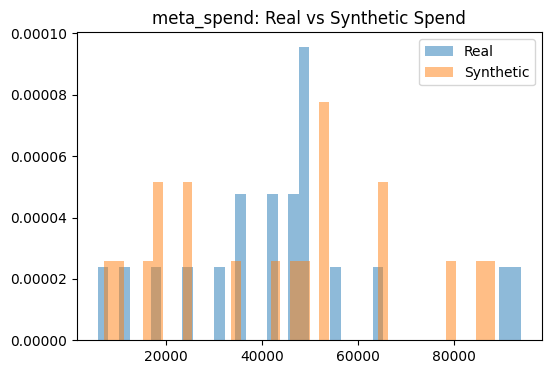

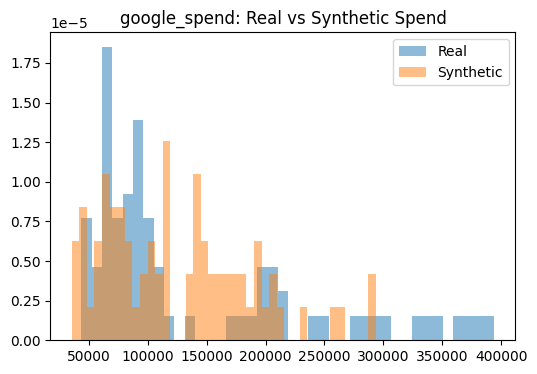

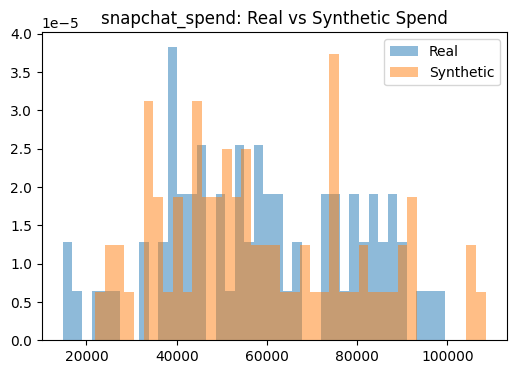

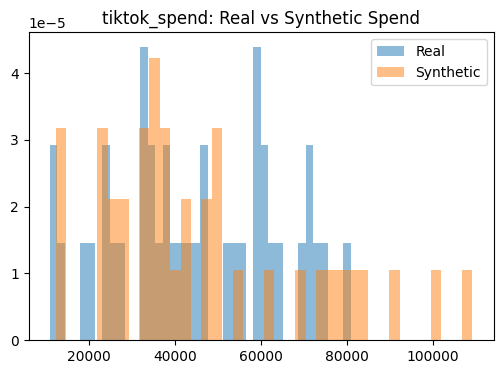

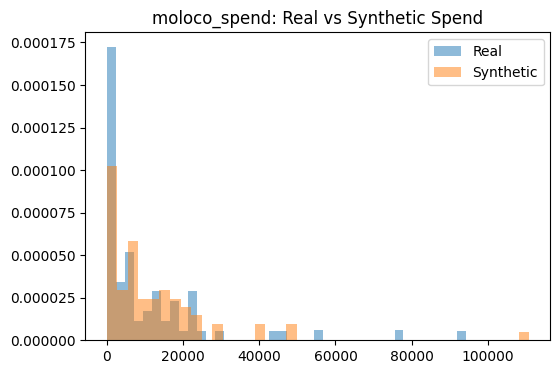

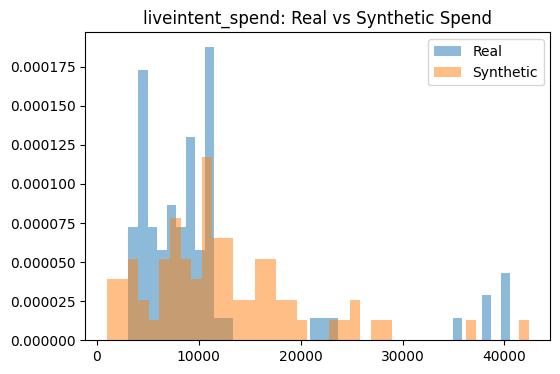

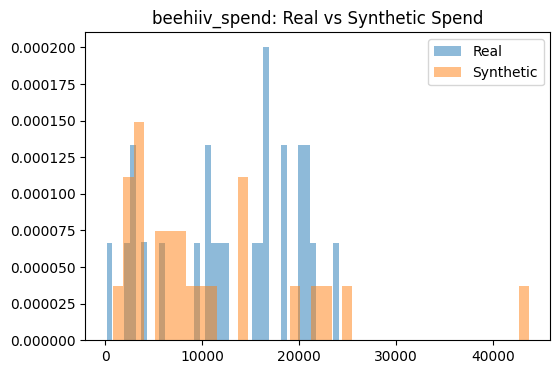

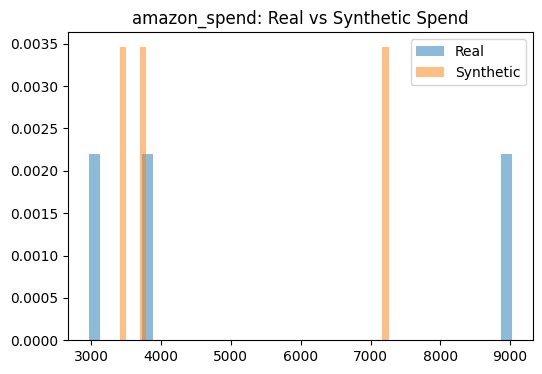

In [54]:
rng = np.random.default_rng(seed=57)

for col in spend_cols:
    real = nonzero_df[col]

    shape = gamma_params[col]["shape"]
    scale = gamma_params[col]["scale"]

    synthetic = rng.gamma(shape, scale = scale, size=len(real))

    plt.figure(figsize=(6,4))

    plt.hist(real, bins=40, density=True, alpha=0.5, label="Real")
    plt.hist(synthetic, bins=40, density=True, alpha=0.5, label="Synthetic")

    plt.title(f"{col}: Real vs Synthetic Spend")
    plt.legend()
    plt.show()

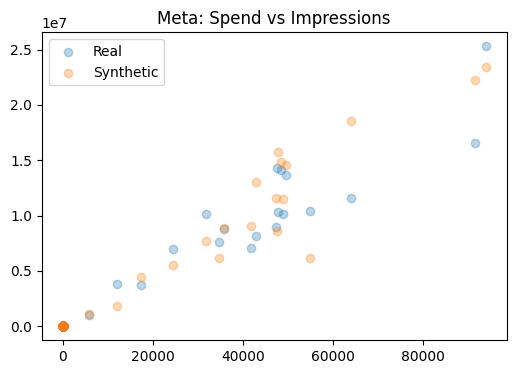

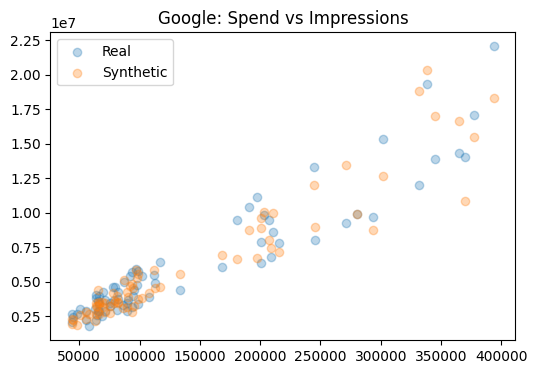

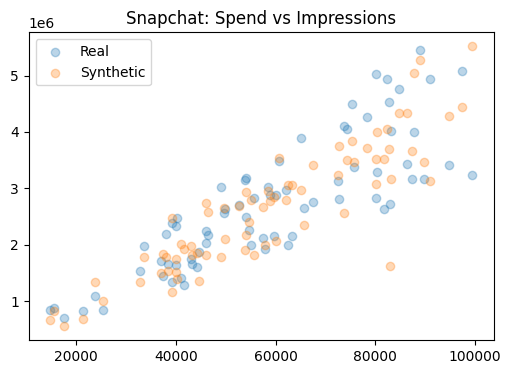

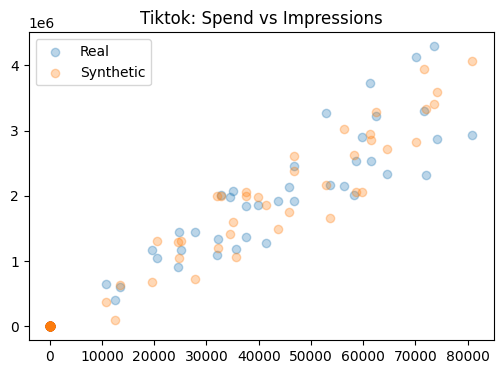

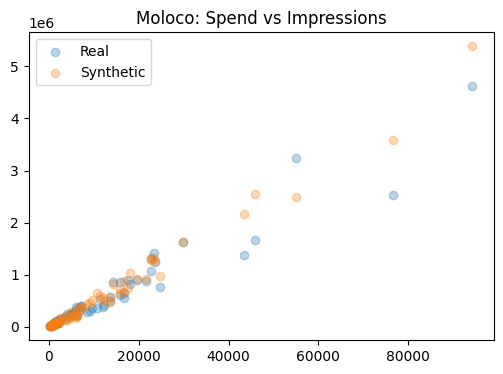

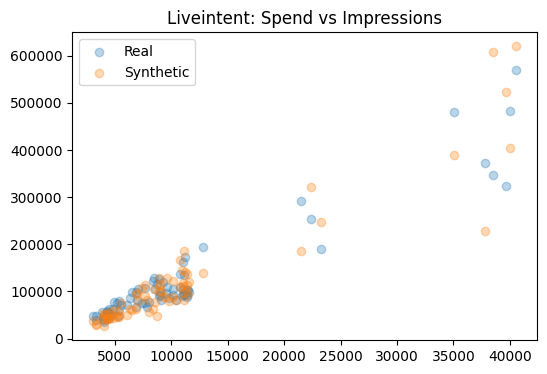

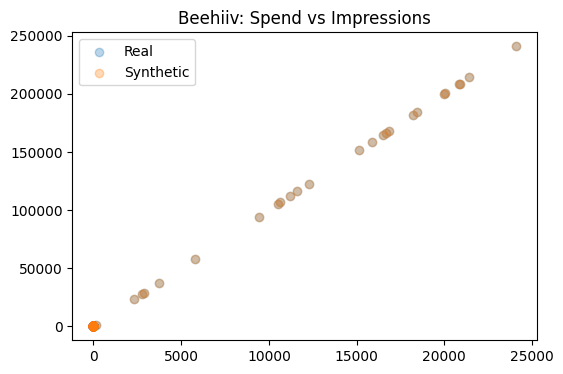

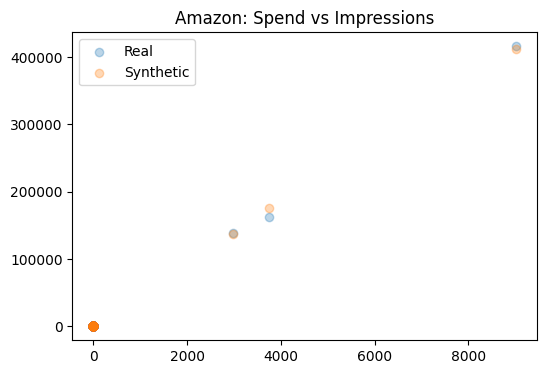

In [57]:
rng = np.random.default_rng(seed=57)
for col in spend_cols:
    imp_col = col.replace("spend", "impressions")

    real_spend = df[col]
    real_imp = df[imp_col]

    alpha = impression_params[col]["alpha"]
    sigma_rel = impression_params[col]["sigma_rel"]

    synthetic_imp = alpha * real_spend * (
        1 + rng.normal(0, sigma_rel, size=len(real_spend))
    )

    plt.figure(figsize=(6,4))
    plt.scatter(real_spend, real_imp, alpha=0.3, label="Real")
    plt.scatter(real_spend, synthetic_imp, alpha=0.3, label="Synthetic")

    plt.title(col.replace("_spend", "").capitalize() + ": Spend vs Impressions")
    plt.legend()
    plt.show()

In [ ]:
# check Cost per Mille (CPM) stability
for col in spend_cols:
    imp_col = col.replace("spend", "impressions")

    cpm = df[col] / df[imp_col] * 1000

    print(f"{col.replace('_spend', '').capitalize()} CPM mean: {np.nanmean(cpm):3f}, std: {np.nanstd(cpm):3f}")

Meta CPM mean: 4.476549, std: 0.917876
Google CPM mean: 22.531886, std: 4.742889
Snapchat CPM mean: 22.598092, std: 4.741219
Tiktok CPM mean: 22.660738, std: 4.849708
Moloco CPM mean: 22.561682, std: 4.854083
Liveintent CPM mean: 90.460839, std: 18.995822
Beehiiv CPM mean: 100.002775, std: 0.010900
Amazon CPM mean: 22.080630, std: 0.776236


With the generators successfully validated, we define the final relation between impressions and revenue. For this iteration, we assume that the relationship is linear, where
$$
Revenue_{t,c} = \beta_c \cdot Impressions_{t,c} \cdot (1 + \eta_{t,c}), \quad \eta_{t,c} \sim \mathcal{N}(0, \sigma_{imp}^2).
$$

With this, we are ready to construct a generator that takes the following inputs:

- channels: n number of channels
- time_periods: t number of time steps (typically weeks)
- ROI: a list of individual channel ROIs of length n

and outputs a synthetic dataset with t observations and n columns and a ground truth file containing the true ROIs. The dataset contains

- spend
- impressions
- revenue

as the features, where revenue is calculated based on the given ROI and generated spend values.

In [ ]:
def generate_MMM_data(
        channels, 
        time_periods, 
        ROIs, 
        sigma_rev=0.1,     # relative revenue noise (eta)
        seed=0, 
        clip_nonnegative=True
):
    
    """
    Returns:
        df_wide: DataFrame with shape (time_periods, 3*len(channels)+1) containing
                {channel}_spend, {channel}_impressions, {channel}_revenue for each channel, and total_revenue
        ground_truth: dict containing ROI, alpha, beta, gamma params, noise params per channel
    """
    rng = np.random.default_rng(seed = seed)

    # prepare containers for wide data
    out = {"time": np.arange(time_periods)}

    ground_truth = {
        "seed": seed,
        "assumptions": {
            "sigma_rev_default": sigma_rev,
            "clip_nonnegative": clip_nonnegative
        },
        "channels": list(channels),
        "params": {}
    }
    total_spend = np.zeros(time_periods)
    total_revenue = np.zeros(time_periods)

    for channel in channels:
        spend_key = f"{channel}_spend"
        imp_key = f"{channel}_impressions"
        rev_key = f"{channel}_revenue"

        # spend distribution params
        shape = gamma_params[spend_key]["shape"]
        scale = gamma_params[spend_key]["scale"]

        # spend -> impressions params
        alpha = impression_params[spend_key]["alpha"]
        sigma_imp = impression_params[spend_key]["sigma_rel"]

        # solve for beta w/ given channel ROI and alpha
        roi = ROIs[channel]
        beta = roi / alpha # dollars per impression (expectation)

        # generate vectors for spend, impressions, revenue
        spend = rng.gamma(shape, scale=scale, size=time_periods)
        eps = rng.normal(0, sigma_imp, size=time_periods)
        eta = rng.normal(0, sigma_rev, size=time_periods)

        impressions = alpha * spend * (1 + eps)
        revenue = beta * impressions * (1 + eta)

        if clip_nonnegative:
            impressions = np.clip(impressions, 0, None)
            revenue = np.clip(revenue, 0, None)

        out[spend_key] = spend
        out[imp_key] = impressions
        out[rev_key] = revenue

        total_spend += spend
        total_revenue += revenue

        ground_truth["params"][channel] = {
            "ROI": roi,
            "alpha": alpha,
            "beta": beta,
            "gamma_shape": shape,
            "gamma_scale": scale,
            "sigma_imp": sigma_imp,
            "sigma_rev": sigma_rev
        }

    out["total_spend"] = total_spend
    out["total_revenue"] = total_revenue

    df_wide = pd.DataFrame(out)
    return df_wide, ground_truth

In [ ]:
# test run
df_synth, gt = generate_MMM_data(
    channels = ["meta", "google"],
    time_periods = 36,
    ROIs = {
        "meta": 2.0,
        "google": 3.0
    },
    sigma_rev=0.1
)

print(df_synth.shape)
print(df_synth.columns[:10])
print(df_synth.head())
print(gt["params"].keys())

(36, 9)
Index(['time', 'meta_spend', 'meta_impressions', 'meta_revenue',
       'google_spend', 'google_impressions', 'google_revenue', 'total_spend',
       'total_revenue'],
      dtype='object')
   time    meta_spend  meta_impressions   meta_revenue   google_spend  \
0     0  42601.040208      1.184307e+07   81239.695781  148854.226551   
1     1  56597.840362      1.097554e+07  100901.945505   23048.942197   
2     2  28282.028912      9.061777e+06   75543.775222   66867.158367   
3     3  78770.193151      1.240649e+07  111014.398633   99111.626528   
4     4  25243.358515      4.838145e+06   42499.984920   64393.427504   

   google_impressions  google_revenue    total_spend  total_revenue  
0        5.281070e+06   391199.971542  191455.266759  472439.667323  
1        1.682989e+06   125223.072000   79646.782559  226125.017505  
2        2.876619e+06   184049.692453   95149.187279  259593.467675  
3        2.429474e+06   169280.950955  177881.819678  280295.349587  
4        2.41

In [85]:
# true ROIs:
for channel in gt["channels"]:
    total_roi = 0
    for i in np.arange(df_synth.shape[0]):
        roi_i = df_synth.iloc[i][f"{channel}_revenue"] / df_synth.iloc[i][f"{channel}_spend"] if df_synth.iloc[i][f"{channel}_spend"] > 0 else 0
        total_roi += roi_i
    avg_roi = total_roi / df_synth.shape[0]
    print(f"Average ROI for channel {channel}: {avg_roi:.3f} vs true ROI: {gt['params'][channel]['ROI']:.3f}")

Average ROI for channel meta: 2.025 vs true ROI: 2.000
Average ROI for channel google: 2.856 vs true ROI: 3.000
